In [1]:
import pandas as pd
import numpy as np

In [2]:
purchase = pd.read_csv(r'C:\Users\karan\Desktop\Project\New Quantium\QVI_purchase_behaviour.csv')

purchase.shape

(72637, 3)

In [3]:
purchase.head(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [5]:
purchase.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [7]:
purchase.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [8]:
purchase.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [9]:
purchase.duplicated().sum()

np.int64(0)

In [10]:
purchase.isna().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [13]:
purchase.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
purchase['LIFESTAGE'].value_counts()


LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [17]:
purchase['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [18]:
transactions = pd.read_excel(r"C:\Users\karan\Desktop\Project\New Quantium\QVI_transaction_data.xlsx")

transactions.info()
transactions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [19]:
transactions['DATE'] = pd.to_datetime(transactions['DATE'], unit='D', origin='1899-12-30')
transactions['DATE'].min(), transactions['DATE'].max()

(Timestamp('2018-07-01 00:00:00'), Timestamp('2019-06-30 00:00:00'))

In [20]:
transactions[['PROD_QTY', 'TOT_SALES']].describe()

,PROD_QTY,TOT_SALES
count,264836.000000,264836.000000
mean,1.907309,7.304200
std,0.643654,3.083226
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [21]:
transactions[transactions['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [22]:
outlier_card = transactions.loc[transactions['PROD_QTY'] == 200, 'LYLTY_CARD_NBR'].iloc[0]
transactions = transactions[transactions['LYLTY_CARD_NBR'] != outlier_card].copy()

transactions.shape   # should now be 264836 - 2 = 264834|

(264834, 8)

In [23]:
transactions.duplicated().sum()

np.int64(1)

In [24]:
transactions[transactions.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [25]:
transactions = transactions.drop_duplicates()

In [26]:
transactions[transactions['PROD_NAME'].str.contains('salsa', case=False)]['PROD_NAME'].unique()

array(['Old El Paso Salsa   Dip Tomato Mild 300g',
       'Red Rock Deli SR    Salsa & Mzzrlla 150g',
       'Smiths Crinkle Cut  Tomato Salsa 150g',
       'Doritos Salsa       Medium 300g',
       'Old El Paso Salsa   Dip Chnky Tom Ht300g',
       'Woolworths Mild     Salsa 300g',
       'Old El Paso Salsa   Dip Tomato Med 300g',
       'Woolworths Medium   Salsa 300g', 'Doritos Salsa Mild  300g'],
      dtype=object)

In [27]:
sorted(transactions['PROD_NAME'].unique())

['Burger Rings 220g',
 'CCs Nacho Cheese    175g',
 'CCs Original 175g',
 'CCs Tasty Cheese    175g',
 'Cheetos Chs & Bacon Balls 190g',
 'Cheetos Puffs 165g',
 'Cheezels Cheese 330g',
 'Cheezels Cheese Box 125g',
 'Cobs Popd Sea Salt  Chips 110g',
 'Cobs Popd Sour Crm  &Chives Chips 110g',
 'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g',
 'Dorito Corn Chp     Supreme 380g',
 'Doritos Cheese      Supreme 330g',
 'Doritos Corn Chip Mexican Jalapeno 150g',
 'Doritos Corn Chip Southern Chicken 150g',
 'Doritos Corn Chips  Cheese Supreme 170g',
 'Doritos Corn Chips  Nacho Cheese 170g',
 'Doritos Corn Chips  Original 170g',
 'Doritos Mexicana    170g',
 'Doritos Salsa       Medium 300g',
 'Doritos Salsa Mild  300g',
 'French Fries Potato Chips 175g',
 'Grain Waves         Sweet Chilli 210g',
 'Grain Waves Sour    Cream&Chives 210G',
 'GrnWves Plus Btroot & Chilli Jam 180g',
 'Infuzions BBQ Rib   Prawn Crackers 110g',
 'Infuzions Mango     Chutny Papadums 70g',
 'Infuzions SourCream&Herbs Veg St

In [28]:
non_chip_products = [
    'Doritos Salsa       Medium 300g',
    'Doritos Salsa Mild  300g',
    'Old El Paso Salsa   Dip Chnky Tom Ht300g',
    'Old El Paso Salsa   Dip Tomato Med 300g',
    'Old El Paso Salsa   Dip Tomato Mild 300g',
    'Woolworths Medium   Salsa 300g',
    'Woolworths Mild     Salsa 300g',
    'Smiths Crinkle Cut  French OnionDip 150g'
]

transactions = transactions[~transactions['PROD_NAME'].isin(non_chip_products)]
transactions.shape

(248229, 8)

In [29]:
transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract(r'(\d+)\s*[gG]')[0].astype(int)
transactions['PACK_SIZE'].describe()

count    248229.000000
mean        175.429958
std          59.286542
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

In [32]:
transactions['BRAND'] = transactions['PROD_NAME'].str.strip().str.split().str[0]
transactions['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        27421
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
CCs            4551
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

In [35]:
transactions[transactions['BRAND']=='French']['PROD_NAME'].unique()


array(['French Fries Potato Chips 175g'], dtype=object)

In [34]:
transactions[transactions['BRAND']=='Burger']['PROD_NAME'].unique()

array(['Burger Rings 220g'], dtype=object)

In [36]:
brand_fix = {
    'WW': 'Woolworths',
    'Red': 'RRD',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'Infzns': 'Infuzions',
    'GrnWves': 'Grain',
    'NCC': 'Natural',
    'Snbts': 'Sunbites'
}
transactions['BRAND'] = transactions['BRAND'].replace(brand_fix)
transactions['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        30384
Doritos       25224
Pringles      25102
RRD           17779
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
Grain          7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Sunbites       3008
Cheetos        2927
Burger         1564
French         1418
Name: count, dtype: int64

In [38]:
data = transactions.merge(purchase, on='LYLTY_CARD_NBR', how='left')
data.shape

(248229, 12)

In [39]:
data['LIFESTAGE'].isna().sum()


np.int64(0)

In [40]:
data['PREMIUM_CUSTOMER'].isna().sum()

np.int64(0)

In [41]:
data.to_csv("QVI_data.csv", index=False)

In [42]:
segment_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_sales=('TOT_SALES', 'sum'),
    n_customers=('LYLTY_CARD_NBR', 'nunique'),
    n_transactions=('TXN_ID', 'nunique'),
    total_units=('PROD_QTY', 'sum')
).reset_index()

segment_summary['avg_spend_per_customer'] = segment_summary['total_sales'] / segment_summary['n_customers']
segment_summary['avg_units_per_customer'] = segment_summary['total_units'] / segment_summary['n_customers']
segment_summary['avg_price_per_unit'] = segment_summary['total_sales'] / segment_summary['total_units']
segment_summary['avg_transactions_per_customer'] = segment_summary['n_transactions'] / segment_summary['n_customers']

segment_summary.sort_values('total_sales', ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,n_customers,n_transactions,total_units,avg_spend_per_customer,avg_units_per_customer,avg_price_per_unit,avg_transactions_per_customer
6,OLDER FAMILIES,Budget,157612.95,4617,21463,42130,34.137524,9.124973,3.741110,4.648690
19,YOUNG SINGLES/COUPLES,Mainstream,147999.20,7921,19571,36379,18.684409,4.592728,4.068259,2.470774
13,RETIREES,Mainstream,145837.35,6369,20009,37925,22.897998,5.954624,3.845415,3.141623
15,YOUNG FAMILIES,Budget,130352.25,3959,17748,34718,32.925549,8.769386,3.754601,4.482950
9,OLDER SINGLES/COUPLES,Budget,128130.00,4856,17143,32991,26.385914,6.793863,3.883786,3.530272
10,OLDER SINGLES/COUPLES,Mainstream,125178.10,4866,17059,32803,25.725051,6.741266,3.816056,3.505754
11,OLDER SINGLES/COUPLES,Premium,124067.05,4692,16575,31892,26.442253,6.797101,3.890225,3.532609
12,RETIREES,Budget,106276.00,4387,14216,27065,24.225211,6.169364,3.926695,3.240483
7,OLDER FAMILIES,Mainstream,96927.25,2790,13225,25996,34.740950,9.317563,3.728545,4.740143
14,RETIREES,Premium,91668.55,3818,12253,23404,24.009573,6.129911,3.916790,3.209272


1. Two different patterns drive the top of total sales:

Older Families (Budget) and Young Families (Budget) get to the top with a smaller customer base (4,617 and 3,959 respectively) but the highest average spend per customer (~$34, ~$33). They're high-value households — fewer of them, but each one spends a lot.
Young Singles/Couples (Mainstream) and Retirees (Mainstream) get to the top with a much larger customer base (7,921 and 6,369) but only moderate average spend (~$19, ~$23). They're getting there on volume of customers, not depth of spend per customer.

So it's the same total-sales rank, but for opposite reasons — one group is "fewer, heavier spenders," the other is "more, lighter spenders."

2. Families consistently have the highest units/customer and transactions/customer, regardless of Budget/Mainstream/Premium tier. Look down the table: Older Families and Young Families (all three tiers) sit around 8.7–9.3 units/customer and 4.4–4.7 transactions/customer — noticeably higher than every other lifestage, which mostly sit in the 4–7 units and 2.3–3.5 transaction range. That says families are the true heavy consumers on a per-household basis — they buy chips more often and in more quantity than singles, couples, or retirees, independent of what tier they're in.

3. Within Young Singles/Couples and Midage Singles/Couples, Mainstream pays the highest price per unit in both cases ($4.07 and $3.99), noticeably above their Budget and Premium counterparts in the same lifestage (~$3.68–3.77 for Young S/C, ~$3.75–3.77 for Midage S/C). That's a bit counterintuitive — you'd expect "Premium" tier to pay the most — but it suggests Mainstream shoppers in these younger lifestages are buying pricier/name-brand packets even though they're not formally tagged "Premium," possibly an impulse/lifestyle purchase rather than a considered "budget" choice.

In [43]:
target = data[(data['PREMIUM_CUSTOMER'] == 'Mainstream') &
              (data['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']))]

rest = data[~data.index.isin(target.index)]

print(target.shape, rest.shape)

(30786, 12) (217443, 12)


In [44]:
target_brand_share = target.groupby('BRAND')['PROD_QTY'].sum()
target_brand_share = target_brand_share / target_brand_share.sum()

rest_brand_share = rest.groupby('BRAND')['PROD_QTY'].sum()
rest_brand_share = rest_brand_share / rest_brand_share.sum()

brand_affinity = (target_brand_share / rest_brand_share).sort_values(ascending=False)
brand_affinity

BRAND
Twisties      1.209174
Kettle        1.195662
Tostitos      1.188480
Doritos       1.170332
Tyrrells      1.166106
Cobs          1.155502
Pringles      1.134538
Infuzions     1.120954
Grain         1.042912
Thins         1.040525
Cheezels      1.005758
Smiths        0.828614
Cheetos       0.725234
RRD           0.702058
Natural       0.689700
French        0.666790
CCs           0.648231
Woolworths    0.532567
Burger        0.514338
Sunbites      0.489056
Name: PROD_QTY, dtype: float64

In [45]:
target_pack_share = target.groupby('PACK_SIZE')['PROD_QTY'].sum()
target_pack_share = target_pack_share / target_pack_share.sum()

rest_pack_share = rest.groupby('PACK_SIZE')['PROD_QTY'].sum()
rest_pack_share = rest_pack_share / rest_pack_share.sum()

pack_affinity = (target_pack_share / rest_pack_share).sort_values(ascending=False)
pack_affinity

PACK_SIZE
270    1.268775
330    1.224111
380    1.211890
110    1.176329
210    1.146508
134    1.134538
135    1.130606
250    1.093299
170    0.991559
175    0.964179
150    0.963276
165    0.899813
190    0.680757
180    0.622705
160    0.589404
70     0.559967
200    0.533354
220    0.514338
125    0.499229
90     0.489056
Name: PROD_QTY, dtype: float64

In [46]:
data[data['PACK_SIZE'].isin([270, 330, 380, 250])]['BRAND'].value_counts()

BRAND
Smiths      9572
Twisties    9454
Doritos     6235
Cheezels    3149
Name: count, dtype: int64

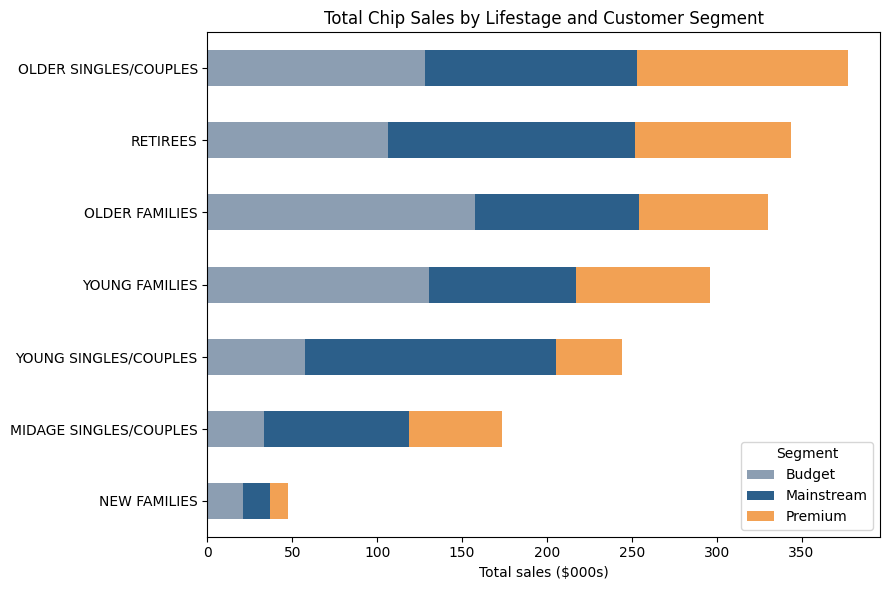

In [47]:
import matplotlib.pyplot as plt

pivot_sales = data.pivot_table(
    index='LIFESTAGE', columns='PREMIUM_CUSTOMER',
    values='TOT_SALES', aggfunc='sum'
) / 1000  # in $000s

pivot_sales = pivot_sales[['Budget', 'Mainstream', 'Premium']]
pivot_sales = pivot_sales.loc[pivot_sales.sum(axis=1).sort_values().index]  # sort ascending

fig, ax = plt.subplots(figsize=(9, 6))
pivot_sales.plot(kind='barh', stacked=True, ax=ax,
                  color=['#8c9eb2', '#2c5f8a', '#f2a154'])

ax.set_xlabel('Total sales ($000s)')
ax.set_ylabel('')
ax.set_title('Total Chip Sales by Lifestage and Customer Segment')
ax.legend(title='Segment', loc='lower right')

plt.tight_layout()
plt.savefig('chart1_total_sales.png', dpi=150)
plt.show()

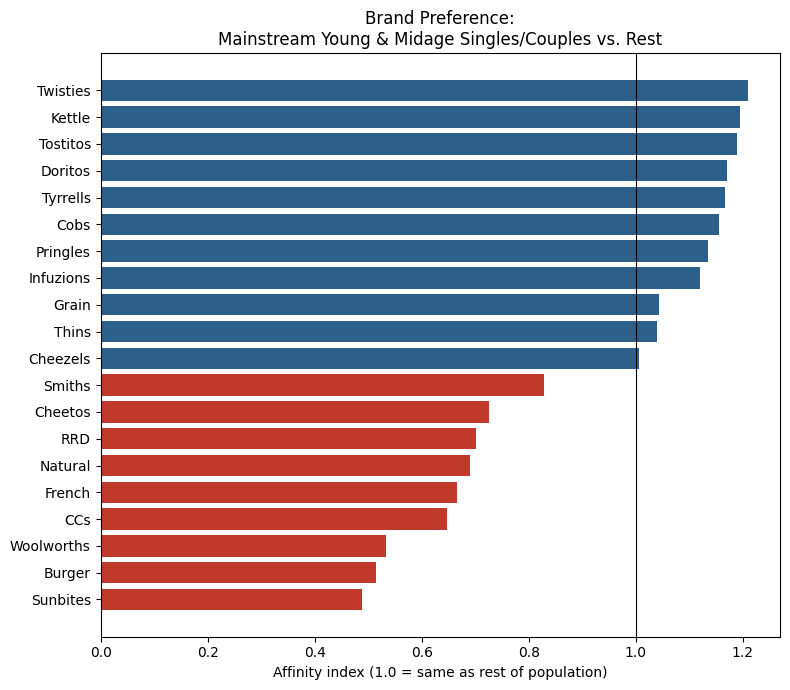

In [48]:
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#c0392b' if v < 1 else '#2c5f8a' for v in brand_affinity.values]
ax.barh(brand_affinity.index[::-1], brand_affinity.values[::-1], color=colors[::-1])

ax.axvline(1, color='black', linewidth=0.8)
ax.set_xlabel('Affinity index (1.0 = same as rest of population)')
ax.set_title('Brand Preference:\nMainstream Young & Midage Singles/Couples vs. Rest')

plt.tight_layout()
plt.savefig('chart2_brand_affinity.png', dpi=150)
plt.show()

### Chip Category Review — Conclusion for Julia
#### Summary of approach: We analysed 12 months of loyalty-card transaction data (Jul 2018–Jun 2019), cleaned it (removed a non-retail commercial buyer, a duplicate record, and 8 non-chip salsa/dip products), and derived pack size and brand from the product names. We then merged this with customer lifestage and spend-tier data to understand who buys chips and what drives their spend.

#### 1. Total sales are concentrated in a small number of segments, but for two different reasons.
Budget – Older Families, Mainstream – Young Singles/Couples, and Mainstream – Retirees contribute the most to total chip sales. However, these segments get there in different ways:

Mainstream Young Singles/Couples and Mainstream Retirees are large in number of customers — their high total sales come from having more shoppers, not from each shopper spending unusually more.
Older and Young Families (particularly Budget tier) get to the same level of total sales with far fewer customers, because each family buys chips far more often and in greater volume per household — around 9 packets/year per customer, versus 4–6 for singles, couples, and retirees.
#### 2. Mainstream Young and Midage Singles/Couples pay more per pack.
Within these two lifestages, Mainstream shoppers pay a statistically significantly higher average unit price ($4.03) than their Budget or Premium counterparts in the same age group ($3.69). This price gap is unlikely to be chance — it points to impulse or occasion-driven buying (chips for entertaining or a treat) rather than routine grocery restocking, where price sensitivity would be higher.

#### 3. This segment has clear, consistent brand and pack-size preferences.
Comparing Mainstream Young & Midage Singles/Couples against the rest of the customer base, they are noticeably more likely to buy Twisties, Kettle, Tostitos, Doritos, Tyrrells, Cobs, and Pringles — and noticeably less likely to buy private-label (Woolworths) and smaller value brands. They also skew toward larger pack formats (270g–380g), though this mostly reflects their brand preference rather than a genuine desire for bigger bags — those larger formats mainly belong to Twisties and Doritos, the very brands they already favour.

Recommendation
Prioritise shelf space and promotional support for Kettle, Doritos, Tostitos, Tyrrells, Cobs, and Pringles in stores that see high foot traffic from Mainstream Young/Midage Singles and Couples — this segment is price-tolerant and already engaged with these brands, so the upside is in visibility and availability rather than discounting.
Protect and grow the family segments with multi-buy or family-pack promotions. They are the heaviest chip consumers per household by a wide margin, and their spend is driven by basket size and shopping frequency rather than price — retention here matters more than acquisition.
Treat Mainstream Young Singles/Couples and Mainstream Retirees as acquisition and retention priorities rather than basket-growth priorities. Their contribution to total sales comes from customer count, so loyalty and new-customer growth in these segments will move total category sales more than trying to get existing customers to spend more.
Suggested next steps
Store-level analysis to identify which physical stores over-index on the target segments, so promotional activity can be geographically targeted.
A basket/cross-category affinity analysis to see what else these segments buy alongside chips, to inform bundling opportunities.
A controlled pilot testing the impact of increased shelf space/off-location for the preferred brands before a full range change.


